# Rossmann Store Sales: Results and Discussion

reads what the modeling notebook saved and does the comparisons, wilcoxon test, complexity vs performance and error analysis.

modeling notebook has to run first for the trainings

## Load the saved results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from pathlib import Path
from scipy.stats import wilcoxon

In [2]:
RES = Path.cwd().parent/"results"
metrics = pd.read_csv(RES/"metrics.csv") # csv's that the modeling notebook has saved
preds = pd.read_csv(RES/"predictions_test.csv", parse_dates=['Date'])
imp = pd.read_csv(RES/"lgbm_importance.csv", index_col= 0)["importance"]
runtimes = pd.read_csv(RES/"runtimes.csv")
print("test preds", preds.shape)
metrics

test preds (30188, 9)


,model,features,split,RMSE,MAE,RMSPE
0,Seasonal Naive,lag7,val,3751.0,2756.5,0.476
1,Seasonal Naive,lag7,test,2595.9,2048.0,0.384
2,Ridge,basic,val,2801.0,1989.5,0.437
3,Ridge,basic,test,2575.6,1892.5,0.449
4,Ridge,engineered,val,1390.7,982.5,0.193
5,Ridge,engineered,test,1095.9,813.4,0.190
6,LightGBM,basic,val,1696.3,1153.6,0.243
7,LightGBM,basic,test,1559.9,1088.3,0.240
8,LightGBM,engineered,val,917.1,633.8,0.126
9,LightGBM,engineered,test,846.9,598.9,0.124


## Model comparison

Comparing best version of each model

In [3]:
# picking main feature set for each model
main = {"Seasonal Naive" : 'lag7', "Ridge" : "engineered", "LightGBM" : "engineered","TFT" : "deep"}
rows=[]
col=[]

In [4]:
for mdl, feat in main.items():
    for split in ["val","test"]:
        r = metrics[(metrics.model==mdl) & (metrics.features==feat) & (metrics.split==split)].iloc[0]
        rows.append((mdl, split, r.RMSE,r.MAE,r.RMSPE))
comp = pd.DataFrame(rows, columns=["model","split","RMSE","MAE","RMSPE"])
test = comp[comp.split=="test"].set_index('model')[["RMSE","MAE","RMSPE"]].sort_values('RMSE')
test

,RMSE,MAE,RMSPE
model,,,
LightGBM,846.9,598.9,0.124
TFT,877.9,616.2,0.127
Ridge,1095.9,813.4,0.190
Seasonal Naive,2595.9,2048.0,0.384


In [5]:
#Same models on june validation
comp[comp.split=="val"].set_index('model')[["RMSE","MAE","RMSPE"]].sort_values('RMSE')

,RMSE,MAE,RMSPE
model,,,
TFT,837.2,569.6,0.115
LightGBM,917.1,633.8,0.126
Ridge,1390.7,982.5,0.193
Seasonal Naive,3751.0,2756.5,0.476


In [6]:
base = test.loc["Seasonal Naive","RMSE"]
improve = test[["RMSE"]].copy()
improve["Improvement Over Baseline (%)"] = (((base-improve.RMSE)/base) *100).round(1)
#improve["Improvement Over Baseline (%)"] = (((base-improve.RMSE)/base) *100)
improve

,RMSE,Improvement Over Baseline (%)
model,,
LightGBM,846.9,67.4
TFT,877.9,66.2
Ridge,1095.9,57.8
Seasonal Naive,2595.9,0.0


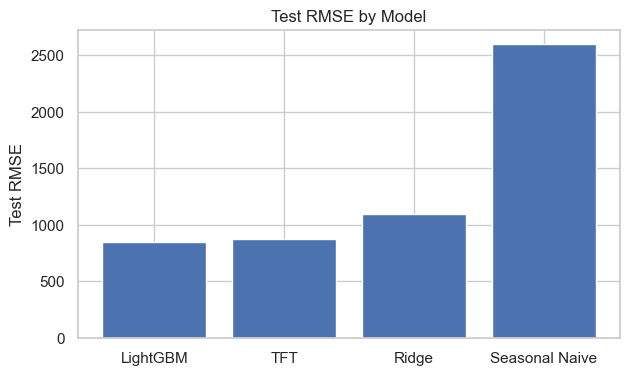

In [7]:
plt.figure(figsize=(7,4))
plt.bar(test.index, test["RMSE"])
plt.title("Test RMSE by Model")
plt.ylabel("Test RMSE")
plt.xticks(rotation=0)
plt.show()